# Introduction to Scikit-learn

This notebook provides a beginner-friendly introduction to Scikit-learn, the most widely used machine-learning library in Python.

**What is Scikit-learn?**
- Built on top of NumPy, SciPy, and Matplotlib
- Provides simple, efficient tools for data mining and machine learning
- Includes classification, regression, clustering, dimensionality reduction, and preprocessing
- Uses a consistent estimator API: `fit()`, `predict()`, `transform()`
- Great for learning ML concepts and building real models quickly

> **Note:** This notebook is a work in progress. Topics will be expanded as I continue learning Scikit-learn.

## 0. Imports

Scikit-learn is conventionally imported piece-by-piece from its submodules, because each task (datasets, preprocessing, models, etc.) lives in its own subpackage.

In [1]:
# Core Scikit-learn imports
from sklearn.datasets import (
    load_breast_cancer,
    load_iris,
    fetch_california_housing,
    fetch_openml,
    make_blobs,
    make_moons,
)
from sklearn.model_selection import (
    train_test_split,
    StratifiedShuffleSplit,
    cross_val_score,
    GridSearchCV,
)
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OrdinalEncoder, OneHotEncoder
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    r2_score,
    mean_absolute_error,
    mean_squared_error,
    root_mean_squared_error,
)

# Classification models
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB

# Regression models
from sklearn.linear_model import LinearRegression, Lasso, Ridge, ElasticNet
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor

# Supporting libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn

np.__version__, pd.__version__, sklearn.__version__


('2.5.1', '3.0.5', '1.9.0')

## 1. Usage of Scikit-learn

Scikit-learn ships with small built-in datasets (toy datasets), larger real-world datasets you can download, and helpers to generate synthetic data.

**Core concepts used throughout this notebook:**
- **Features (`X`)**: the input data â€” usually a 2D array where each row is a sample and each column is a feature.
- **Target (`y`)**: the label/output you want to predict â€” usually a 1D array.
- **Estimator**: any object that learns from data (e.g. a classifier or regressor).
- **`fit()`**: train a model on data.
- **`predict()`**: make predictions from a trained model.
- **`transform()`**: apply a preprocessing step (e.g. scaling) to data.
- **`fit_transform()`**: combine `fit()` + `transform()` in one step (only on training data).


### Real-world datasets

Most loaders return a `Bunch` object (like a dict). With `as_frame=True` you can get a pandas DataFrame, or use `return_X_y=True` to get plain NumPy arrays.

In [2]:
# Load a classic binary classification dataset as a DataFrame
df = load_breast_cancer(as_frame=True).frame
df

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,0.05623,...,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115,0
565,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,0.05533,...,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637,0
566,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,0.05648,...,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820,0
567,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,0.07016,...,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400,0


In [3]:
# Same dataset, returned as plain (X, y) NumPy arrays
X, y = load_breast_cancer(return_X_y=True)
X.shape, y.shape

((569, 30), (569,))

In [4]:
# Regression dataset: California housing (median house value per district)
df = fetch_california_housing(as_frame=True).frame
df

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422
...,...,...,...,...,...,...,...,...,...
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09,0.781
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,-121.21,0.771
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22,0.923
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32,0.847


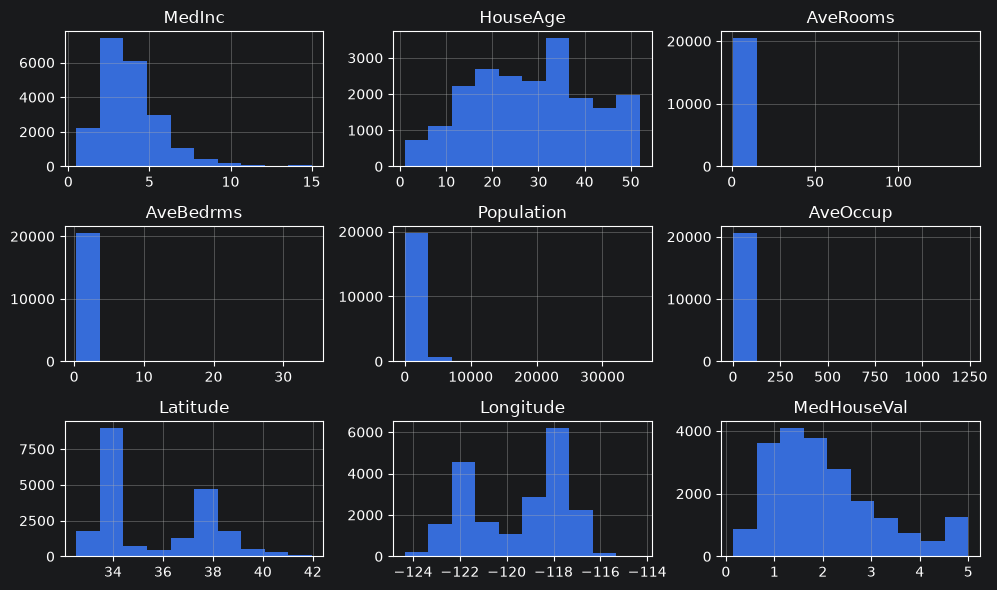

In [5]:
# Quick visual overview of feature distributions
df.hist(figsize=(10, 6))
plt.tight_layout()
plt.show()

In [6]:
# Numerical summary of each numeric column
df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


In [7]:
# Column names and types (plus non-null counts)
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


### Synthetic datasets

Useful for experimentation and visualization because you control the shape, clusters, and noise.


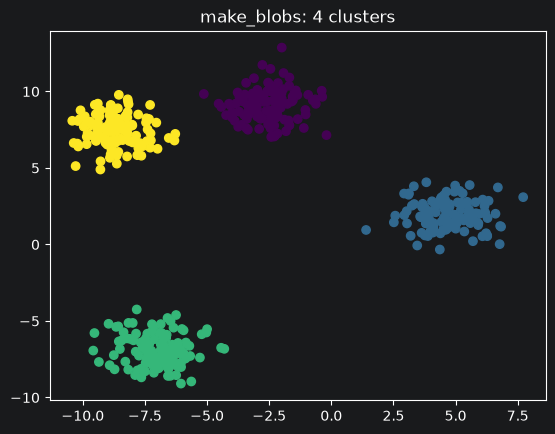

In [8]:
# make_blobs: isotropic Gaussian blobs (great for clustering / classification demos)
X, y = make_blobs(n_samples=500, centers=4, n_features=2, random_state=42)
plt.scatter(X[:, 0], X[:, 1], c=y)
plt.title("make_blobs: 4 clusters")
plt.show()

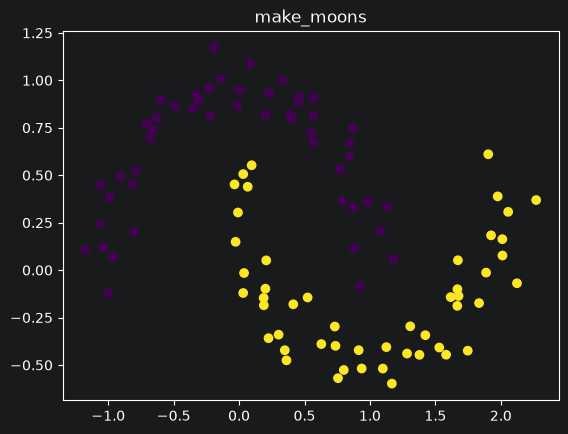

In [9]:
# make_moons: two interleaving half-moons (good for non-linear classifiers)
X, y = make_moons(noise=0.1, random_state=42)
plt.scatter(X[:, 0], X[:, 1], c=y)
plt.title("make_moons")
plt.show()

## 2. Train / Test Split

Always evaluate a model on data it has **not** seen during training. `train_test_split` gives you a quick random split, while `StratifiedShuffleSplit` preserves the class distribution in each split (important for imbalanced data).

In [10]:
# Quick random split (default: 80% train / 20% test)
X, y = load_iris(return_X_y=True)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

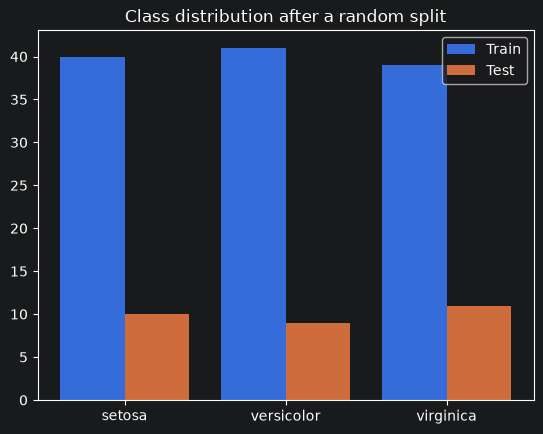

In [11]:
# Always check the class distribution after splitting
train_counts = np.bincount(y_train)
test_counts = np.bincount(y_test)

positions = np.arange(3)
plt.bar(positions - 0.2, train_counts, width=0.4, label="Train")
plt.bar(positions + 0.2, test_counts, width=0.4, label="Test")
plt.xticks(positions, load_iris().target_names)
plt.legend()
plt.title("Class distribution after a random split")
plt.show()

In [12]:
# Stratified split: keeps the same class ratio in train and test
split = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)

for train_idx, test_idx in split.split(X, y):
    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

np.bincount(y_train)
np.bincount(y_test)


array([10, 10, 10])

## 3. Preprocessing: Scaling

Many models (KNN, SVM, Logistic Regression, regularized linear models) perform much better when features are on a similar scale.

**Key rule:** fit the scaler on the training set only, then apply the same transformation to train and test.

In [13]:
# StandardScaler: zero mean, unit variance (the most common choice)
X, y = load_iris(return_X_y=True)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)   # learn stats + apply to train
X_test_scaled = scaler.transform(X_test)         # apply the same stats to test
X_train_scaled[:3]

array([[-1.47393679,  1.20365799, -1.56253475, -1.31260282],
       [-0.13307079,  2.99237573, -1.27600637, -1.04563275],
       [ 1.08589829,  0.08570939,  0.38585821,  0.28921757]])

In [14]:
# MinMaxScaler: scale each feature into a given range (default [0, 1])
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
X_train_scaled[:3]

array([[0.08823529, 0.66666667, 0.        , 0.04166667],
       [0.41176471, 1.        , 0.0877193 , 0.125     ],
       [0.70588235, 0.45833333, 0.59649123, 0.54166667]])

## 4. Preprocessing: Encoding Categorical Features

Scikit-learn estimators work with numbers, so text/categorical columns must be converted first.

- **`OrdinalEncoder`**: map each category to an integer (assumes an order, or use when categories are inherently ordered like `low < med < high`).
- **`OneHotEncoder`**: create one binary column per category (safer for nominal data â€” no implied ordering).

In [15]:
# OrdinalEncoder: assign an integer per category
df = fetch_openml('car', as_frame=True).frame
df.head()

C:\Users\Lenovo\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\datasets\_openml.py:328: UserWarning: Multiple active versions of the dataset matching the name car exist. Versions may be fundamentally different, returning version 2. Available versions:
- version 2, status: active
  url: https://www.openml.org/search?type=data&id=991
- version 3, status: active
  url: https://www.openml.org/search?type=data&id=40975

  warn(warning_msg)


,buying,maint,doors,persons,lug_boot,safety,binaryClass
0,vhigh,vhigh,2,2,small,low,P
1,vhigh,vhigh,2,2,small,med,P
2,vhigh,vhigh,2,2,small,high,P
3,vhigh,vhigh,2,2,med,low,P
4,vhigh,vhigh,2,2,med,med,P


In [16]:
columns_to_encode = ['lug_boot', 'safety']
encoder = OrdinalEncoder(categories=[
    ['small', 'med', 'big'],   # explicit order for lug_boot
    ['low', 'med', 'high'],    # explicit order for safety
])

df[columns_to_encode] = encoder.fit_transform(df[columns_to_encode])
df[columns_to_encode].head()

,lug_boot,safety
0,0.0,0.0
1,0.0,1.0
2,0.0,2.0
3,1.0,0.0
4,1.0,1.0


In [17]:
# inverse_transform: turn the encoded integers back into the original strings
encoder.inverse_transform(df[columns_to_encode])

array([['small', 'low'],
       ['small', 'med'],
       ['small', 'high'],
       ...,
       ['big', 'low'],
       ['big', 'med'],
       ['big', 'high']], shape=(1728, 2), dtype=object)

In [18]:
# OneHotEncoder: one binary column per category value
data = fetch_openml('adult', as_frame=True).frame
data[['occupation', 'race']].head()

C:\Users\Lenovo\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\datasets\_openml.py:328: UserWarning: Multiple active versions of the dataset matching the name adult exist. Versions may be fundamentally different, returning version 1. Available versions:
- version 1, status: active
  url: https://www.openml.org/search?type=data&id=179
- version 2, status: active
  url: https://www.openml.org/search?type=data&id=1590

  warn(warning_msg)


,occupation,race
0,Adm-clerical,White
1,Exec-managerial,White
2,Handlers-cleaners,White
3,Handlers-cleaners,Black
4,Prof-specialty,Black


In [19]:
# sparse_output=True keeps the result memory-efficient for high-cardinality columns
encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=True)
encoded_values = encoder.fit_transform(data[['occupation', 'race']])
new_cols = encoder.get_feature_names_out(['occupation', 'race'])

df_encoded = pd.DataFrame.sparse.from_spmatrix(
    encoded_values,
    columns=new_cols,
    index=data.index,
)

data_final = pd.concat(
    [data.drop(columns=['occupation', 'race']), df_encoded],
    axis=1,
)
data_final.head()

,age,workclass,fnlwgt,education,education-num,marital-status,relationship,sex,capitalgain,capitalloss,...,occupation_Protective-serv,occupation_Sales,occupation_Tech-support,occupation_Transport-moving,occupation_nan,race_Amer-Indian-Eskimo,race_Asian-Pac-Islander,race_Black,race_Other,race_White
0,2,State-gov,77516,Bachelors,13,Never-married,Not-in-family,Male,1,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0
1,3,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Husband,Male,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0
2,2,Private,215646,HS-grad,9,Divorced,Not-in-family,Male,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0
3,3,Private,234721,11th,7,Married-civ-spouse,Husband,Male,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN
4,1,Private,338409,Bachelors,13,Married-civ-spouse,Wife,Female,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN


## 5. Classification

All classifiers in Scikit-learn follow the same API:
1. Create the model: `clf = SomeClassifier()`
2. Train it: `clf.fit(X_train, y_train)`
3. Evaluate: `clf.score(X_test, y_test)` (returns mean accuracy for classifiers)
4. Predict: `clf.predict(X_test)` or `clf.predict_proba(X_test)` for probabilities

In [20]:
# Common classification models (all share the same fit/predict API)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB

classifiers = {
    "KNN":              KNeighborsClassifier(),
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree":    DecisionTreeClassifier(random_state=42),
    "SVM":              SVC(),
    "Random Forest":    RandomForestClassifier(random_state=42),
    "Naive Bayes":      GaussianNB(),
}

In [21]:
# Prepare the breast-cancer dataset
X, y = load_breast_cancer(return_X_y=True)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [22]:
# Train each classifier and report its test accuracy
results = {
    name: clf.fit(X_train_scaled, y_train).score(X_test_scaled, y_test)
    for name, clf in classifiers.items()
}
pd.Series(results, name="accuracy").sort_values(ascending=False).to_frame()


,accuracy
SVM,0.982456
Logistic Regression,0.973684
Naive Bayes,0.964912
Random Forest,0.964912
KNN,0.947368
Decision Tree,0.947368


In [23]:
# Predict the label for a single new sample
single_instance = X_test_scaled[3]

clf = GaussianNB()
clf.fit(X_train_scaled, y_train)

clf.predict([single_instance])
y_test[0]



np.int64(1)

In [24]:
# predict_proba: class probabilities instead of a hard label
clf.predict_proba([single_instance])

array([[9.80109091e-12, 1.00000000e+00]])

## 6. Regression

Regression models predict a continuous number instead of a class. The workflow is identical to classification â€” same `fit` / `predict` / `score` API. For regressors, `score` returns the **RÂ²** coefficient (1.0 = perfect, 0.0 = predicting the mean, < 0 = worse than the mean).

In [25]:
# Common regression models
from sklearn.linear_model import LinearRegression, Lasso, Ridge, ElasticNet
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor

regressors = {
    "Linear Regression":   LinearRegression(),
    "Ridge":               Ridge(),
    "Lasso":               Lasso(),
    "ElasticNet":          ElasticNet(),
    "KNN":                 KNeighborsRegressor(),
    "Decision Tree":       DecisionTreeRegressor(random_state=42),
    "SVR":                 SVR(),
    "Random Forest":       RandomForestRegressor(random_state=42),
}

In [26]:
# Prepare the California housing dataset
X, y = fetch_california_housing(return_X_y=True)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [27]:
# Train each regressor and report its R-squared on the test set
results = {
    name: reg.fit(X_train_scaled, y_train).score(X_test_scaled, y_test)
    for name, reg in regressors.items()
}
pd.Series(results, name="R-squared").sort_values(ascending=False).to_frame()


,R-squared
Random Forest,0.804706
SVR,0.727564
KNN,0.670010
Decision Tree,0.623791
Ridge,0.575816
Linear Regression,0.575788
ElasticNet,0.203126
Lasso,-0.000219


In [28]:
# Predict the target for a single new sample
reg = LinearRegression()
reg.fit(X_train_scaled, y_train)

single_instance = X_test_scaled[0]
reg.predict([single_instance])
y_test[0]



np.float64(0.477)

## 7. Clustering

Clustering groups samples by similarity without using labels. It's useful for
exploration, customer segmentation, and anomaly detection.

**Two common algorithms in Scikit-learn:**
- **`KMeans`**: you pick the number of clusters `k`; each cluster is a centroid.
- **`DBSCAN`**: density-based; you set a neighborhood radius `eps`. Points in
  sparse regions get the label `-1` (noise).

Both estimators expose the `.labels_` attribute after `fit()`.



Text(0.5, 1.0, 'make_blobs: raw points')

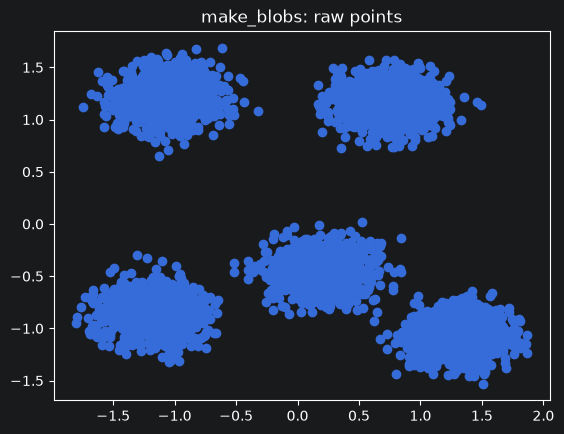

In [29]:
# KMeans on synthetic blobs — straight (unscaled) data and scaled data side by side
X, _ = make_blobs(n_samples=5000, centers=5, random_state=10)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Raw points (no cluster labels yet)
plt.scatter(X_scaled[:, 0], X_scaled[:, 1])
plt.title("make_blobs: raw points")



Text(0.5, 1.0, 'KMeans: 5 clusters on the blobs')

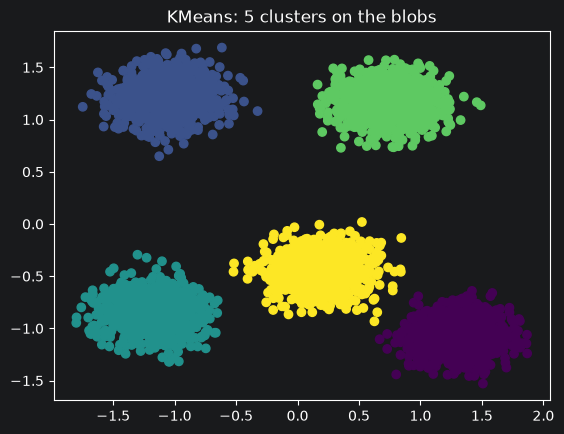

In [30]:
kmeans = KMeans(n_clusters=5, random_state=42)
kmeans.fit(X_scaled)

plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=kmeans.labels_)
plt.title("KMeans: 5 clusters on the blobs")



Text(0.5, 1.0, 'KMeans on half-moons — does NOT separate them well')

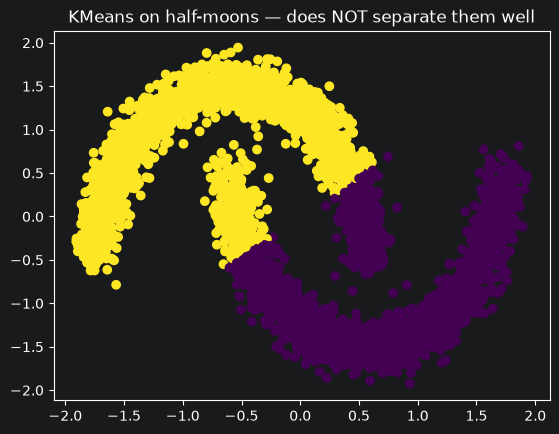

In [31]:
# KMeans on interleaving half-moons — fails because KMeans assumes spherical blobs
X, _ = make_moons(n_samples=4000, noise=0.08)
X_scaled = StandardScaler().fit_transform(X)

kmeans = KMeans(n_clusters=2, random_state=42)
kmeans.fit(X_scaled)

plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=kmeans.labels_)
plt.title("KMeans on half-moons — does NOT separate them well")



Text(0.5, 1.0, 'DBSCAN on half-moons — points with label -1 are noise')

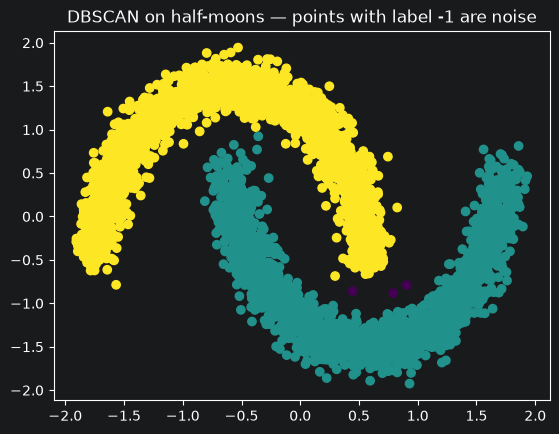

In [32]:
# DBSCAN handles non-spherical shapes with eps as the neighborhood radius
dbscan = DBSCAN(eps=0.2)
dbscan.fit(X_scaled)

plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=dbscan.labels_)
plt.title("DBSCAN on half-moons — points with label -1 are noise")



## 8. Dimensionality Reduction with PCA

**Principal Component Analysis (PCA)** projects data onto the directions of
greatest variance. It's useful for:
- Compressing high-dimensional data (e.g. 784-dim MNIST → 10 components)
- Visualising clusters in 2D / 3D
- Speeding up downstream models

Fit PCA on the training set only, then `.transform()` train and test with
the same model — same rule as for scalers.



In [33]:
# Load MNIST and split once
X, y = fetch_openml('mnist_784', return_X_y=True)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)



In [34]:
# Reduce 784 features down to 10 principal components
pca = PCA(n_components=10)
X_train_reduced = pca.fit_transform(X_train)
X_test_reduced = pca.transform(X_test)



In [35]:
# Compare shapes
X_train.shape, X_train_reduced.shape



((56000, 784), (56000, 10))

In [36]:
# Baseline accuracy on raw MNIST pixels
clf = LogisticRegression(max_iter=100)
clf.fit(X_train, y_train)
clf.score(X_test, y_test)



C:\Users\Lenovo\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


0.9172142857142858

In [37]:
# Accuracy after PCA compression — usually nearly as good, much faster
clf = LogisticRegression(max_iter=100)
clf.fit(X_train_reduced, y_train)
clf.score(X_test_reduced, y_test)



C:\Users\Lenovo\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


0.8006428571428571

In [38]:
# Variance explained by each of the 10 components
pca.explained_variance_ratio_
np.sum(pca.explained_variance_ratio_)



np.float64(0.4893874932032068)

## 9. Metrics

The `score()` method is convenient but coarse. For finer evaluation use the
`sklearn.metrics` module:

**Classification:**
- `accuracy_score` — fraction correct
- `precision_score` — TP / (TP + FP)
- `recall_score` — TP / (TP + FN)
- `f1_score` — harmonic mean of precision and recall

**Regression:**
- `r2_score` — coefficient of determination (1.0 is perfect)
- `mean_absolute_error` — average |error|
- `mean_squared_error` / `root_mean_squared_error` — penalises large errors



In [39]:
# Prepare the breast-cancer dataset and fit a KNN classifier
X, y = load_breast_cancer(return_X_y=True)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

clf = KNeighborsClassifier()
clf.fit(X_train_scaled, y_train)
y_pred = clf.predict(X_test_scaled)



In [40]:
# Quick accuracy via score()
clf.score(X_test_scaled, y_test)



0.9473684210526315

In [41]:
# The four most common classification metrics at once
pd.DataFrame(
    {
        "accuracy":  [accuracy_score(y_test, y_pred)],
        "precision": [precision_score(y_test, y_pred)],
        "recall":    [recall_score(y_test, y_pred)],
        "f1":        [f1_score(y_test, y_pred)],
    },
    index=["KNN"],
)



,accuracy,precision,recall,f1
KNN,0.947368,0.957746,0.957746,0.957746


In [42]:
# Regression metrics — fit a linear regressor on California housing
X, y = fetch_california_housing(return_X_y=True)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

reg = LinearRegression()
reg.fit(X_train_scaled, y_train)
y_pred = reg.predict(X_test_scaled)



In [43]:
# Quick R┬▓ via score()
reg.score(X_test_scaled, y_test)



0.5757877060324508

In [44]:
# Three regression metrics at once
pd.DataFrame(
    {
        "r2":    [r2_score(y_test, y_pred)],
        "mae":   [mean_absolute_error(y_test, y_pred)],
        "rmse":  [root_mean_squared_error(y_test, y_pred)],
    },
    index=["LinearRegression"],
)



,r2,mae,rmse
LinearRegression,0.575788,0.5332,0.745581


## 10. Cross Validation

A single train/test split is noisy. **Cross validation** averages the score
over `cv` different splits, giving a more stable estimate of how the model
generalises. The data is split into `cv` folds; each fold is the test set once.



In [45]:

X, y = load_breast_cancer(return_X_y=True)
X_scaled = StandardScaler().fit_transform(X)



In [46]:
clf = KNeighborsClassifier()
scores = cross_val_score(clf, X_scaled, y, cv=5)
scores



array([0.96491228, 0.95614035, 0.98245614, 0.95614035, 0.96460177])

In [47]:
np.mean(scores)



np.float64(0.9648501785437045)

## 11. Hyperparameter Tuning

Most models expose **hyperparameters** that aren't learned from data
(`n_neighbors` for KNN, `max_depth` for trees, etc.). Picking them manually is
tedious. `GridSearchCV` tries every combination from a grid and uses cross
validation to choose the best one.



In [48]:
X, y = load_breast_cancer(return_X_y=True)
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=0)

# Grid of hyperparameters to try
param_grid = {
    'n_estimators':     [50, 100, 200],
    'max_depth':        [None, 5, 10],
    'min_samples_split': [2, 5],
}



In [49]:

clf = RandomForestClassifier(n_jobs=-1)
grid = GridSearchCV(clf, param_grid, cv=3)

grid.fit(X_train, y_train)



,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ier(n_jobs=-1)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [None, 5, ...], 'min_samples_split': [2, 5], 'n_estimators': [50, 100, ...]}"
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, default=0Contro

In [50]:
grid.best_params_



{'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 50}

In [51]:
# The best estimator is already refit on the full training set
best_clf = grid.best_estimator_
best_clf.score(X_test, y_test)



0.972027972027972

## 12. Pipeline

A `Pipeline` chains preprocessing and an estimator into one object so the same
transformation is applied to every fold in cross validation and to the test
set. Always use a pipeline (or otherwise ensure `fit` only on training data)
to avoid data leakage.



In [52]:
X, y = load_breast_cancer(return_X_y=True)
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=0)


# Chain: scale → PCA → random forest
pipe = Pipeline([
    ('scale',  StandardScaler()),
    ('pca',    PCA(n_components=10)),
    ('forest', RandomForestClassifier()),
])
pipe.fit(X_train, y_train)



,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('scale', ...), ('pca', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,30
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
Name,Type,Value


In [53]:
pipe.score(X_test, y_test)



0.9090909090909091

---
## Scikit-learn Cheat Sheet

Quick reference for every pattern shown above.

### Loading Data
| Function / Flag | Description |
|---|---|
| `load_iris()`, `load_breast_cancer()` | Built-in toy datasets |
| `fetch_california_housing()`, `fetch_openml('name')` | Larger downloadable datasets |
| `make_blobs()`, `make_moons()`, `make_circles()` | Synthetic datasets |
| `as_frame=True` | Return a pandas DataFrame |
| `return_X_y=True` | Return plain `(X, y)` NumPy arrays |

### Train / Test Split
| Function | Description |
|---|---|
| `train_test_split(X, y, test_size=0.2, random_state=42)` | Random split |
| `StratifiedShuffleSplit(n_splits=1, test_size=0.2)` | Split preserving class ratio |

### Preprocessing: Scaling
| Class / Method | Description |
|---|---|
| `StandardScaler()` | Zero mean, unit variance |
| `MinMaxScaler()` | Scale into a range (default `[0, 1]`) |
| `scaler.fit_transform(X_train)` | Learn stats from training data, then apply |
| `scaler.transform(X_test)` | Apply the learned transformation to test data |

### Preprocessing: Encoding
| Class / Method | Description |
|---|---|
| `OrdinalEncoder(categories=[...])` | Map each category to an integer |
| `OneHotEncoder(handle_unknown='ignore')` | One binary column per category |
| `encoder.get_feature_names_out(cols)` | Names of the produced columns |
| `encoder.inverse_transform(X)` | Recover original categories |

### Classification
| Class / Method | Description |
|---|---|
| `KNeighborsClassifier()` | K-Nearest Neighbors |
| `LogisticRegression()` | Linear classifier |
| `DecisionTreeClassifier()` | Single decision tree |
| `SVC()` | Support Vector Classifier |
| `RandomForestClassifier()` | Ensemble of decision trees |
| `GaussianNB()` | Gaussian Naive Bayes |

### Regression
| Class / Method | Description |
|---|---|
| `LinearRegression()` | Ordinary least-squares linear model |
| `Ridge()`, `Lasso()`, `ElasticNet()` | Regularized linear models |
| `KNeighborsRegressor()` | K-Nearest Neighbors regressor |
| `DecisionTreeRegressor()` | Single decision tree regressor |
| `SVR()` | Support Vector Regressor |
| `RandomForestRegressor()` | Ensemble regressor |

### Clustering
| Class / Method | Description |
|---|---|
| `KMeans(n_clusters=k)` | Centroid-based clustering |
| `DBSCAN(eps=0.2)` | Density-based clustering; label `-1` = noise |
| `model.fit(X)` then `model.labels_` | Fit and read off the cluster assignments |

### Dimensionality Reduction
| Class / Method | Description |
|---|---|
| `PCA(n_components=k)` | Project onto top-k principal components |
| `pca.fit_transform(X_train)` / `pca.transform(X_test)` | Same split rule as scalers |
| `pca.explained_variance_ratio_` | Fraction of variance per component |

### Metrics
| Function | Description |
|---|---|
| `accuracy_score(y_true, y_pred)` | Fraction correct (classification) |
| `precision_score(y_true, y_pred)` | TP / (TP + FP) |
| `recall_score(y_true, y_pred)` | TP / (TP + FN) |
| `f1_score(y_true, y_pred)` | Harmonic mean of precision and recall |
| `r2_score(y_true, y_pred)` | Coefficient of determination (regression) |
| `mean_absolute_error(y_true, y_pred)` | Average absolute error |
| `mean_squared_error(...)` / `root_mean_squared_error(...)` | Penalises large errors |

### Cross Validation
| Function | Description |
|---|---|
| `cross_val_score(clf, X, y, cv=5)` | Array of scores over `cv` folds |
| `np.mean(scores)` | Average cross-validated score |

### Hyperparameter Tuning
| Function / Method | Description |
|---|---|
| `GridSearchCV(clf, param_grid, cv=3)` | Try every combination from a grid |
| `grid.fit(X_train, y_train)` | Run the search |
| `grid.best_params_` | Best hyperparameter combination found |
| `grid.best_estimator_` | Refit estimator with the best params |

### Pipeline
| Function / Class | Description |
|---|---|
| `Pipeline([('step', Estimator()), ...])` | Chain preprocessing + final estimator |
| `pipe.fit(X_train, y_train)` | Fit each step on training data in order |
| `pipe.score(X_test, y_test)` | Score the whole chained model on test data |
| `pipe.predict(X)` | Predict through the whole chain |

### Estimator API (all models)
| Method | Description |
|---|---|
| `model.fit(X_train, y_train)` | Train the model |
| `model.predict(X)` | Predict labels / values |
| `model.predict_proba(X)` | Class probabilities (classifiers only) |
| `model.score(X_test, y_test)` | Accuracy (classifiers) or R┬▓ (regressors) |
| `model.transform(X)` | Apply an already-fit preprocessing step |
| `model.fit_transform(X)` | Fit and apply a preprocessing step in one call |

